In [1]:
import numpy as np
import json
from scipy.stats import linregress
import matplotlib.pyplot as plt

In [2]:
# Thread duration
days = np.load('days.npy')
Npost = len(days)
print(Npost)

# Thread size
comments = np.load('comments.npy')
print(len(comments))

# User activity
activity = np.load('activity.npy')
Nuser = len(activity)
print(Nuser)

# Comments in threads
with open('discussionTree.json') as json_file:
    for users in json_file:
        reel = json.loads(users)

postString = list(reel.keys())
for post in postString:
    reel[int(post)] = reel.pop(post)

for post in reel:
    dayString = list(reel[post].keys())
    for d in dayString:
        reel[post][int(d)] = reel[post].pop(d)

print(len(reel))

# User fitness
fitness = np.load('fitness.npy')
print(len(fitness))

100000
100000
450000
100000
450000


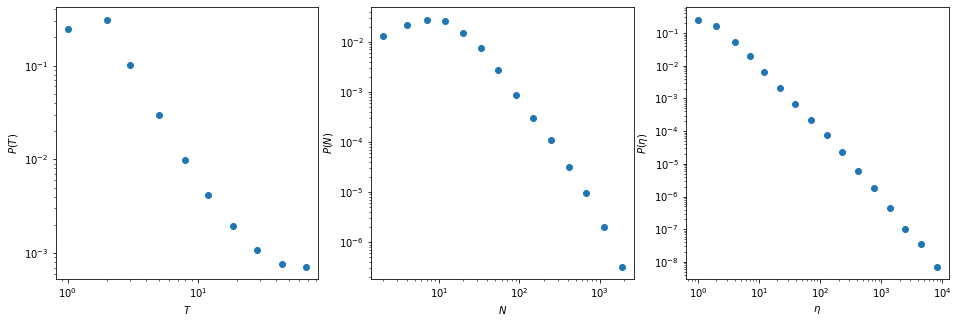

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

# Thread duration
bins = np.concatenate((np.array([1, 2, 3, 5, 8]), np.geomspace(12, max(days), 6)))
modelHist, modelBins = np.histogram(days, bins=bins, density=True)
ax[0].plot(modelBins[:-1], modelHist, marker='o', linestyle='', color='C0')
ax[0].set(xscale='log', yscale='log', xlabel=r'$T$', ylabel=r'$P(T)$')

# Thread size
bins = np.concatenate((np.array([2, 4, 7]), np.geomspace(12, max(comments), 12)))
modelHist, modelBins = np.histogram(comments, bins=bins, density=True)
ax[1].plot(modelBins[:-1], modelHist, marker='o', linestyle='', color='C0')
ax[1].set(xscale='log', yscale='log', xlabel=r'$N$', ylabel=r'$P(N)$')

# User activity
bins = np.concatenate((np.array([1, 2, 4, 7]), np.geomspace(12, max(activity), 13)))
modelHist, modelBins = np.histogram(activity, bins=bins, density=True)
ax[2].plot(modelBins[:-1], modelHist, marker='o', linestyle='', color='C0')
ax[2].set(xscale='log', yscale='log', xlabel=r'$\eta$', ylabel=r'$P(\eta)$')

plt.show()

In [4]:
# Comments' tracking
userTrack = {}
for u in range(Nuser):
    userTrack[u] = []

for post in reel:
    for d in reel[post]:
        for u in reel[post][d]:
            userTrack[u].append(post)

In [5]:
# Rewarding users

deltaReceiver = {}
for u in range(Nuser):
    deltaReceiver[u] = []

np.random.seed(2715)
deltaGiver, deltaDay = {}, {}
for post in reel:
    deltaGiver[post] = {}
    deltaDay[post] = []
    cnt = 0
    for d in reel[post]:
        comday = len(reel[post][d])
        freq = comday/200.
        userSampling = np.array([fitness[u] for u in reel[post][d]])
        userSampling = userSampling*freq/np.sum(userSampling)
        for u,attr in enumerate(userSampling):
            rc = reel[post][d][u]
            if (np.random.uniform(0, 1) < attr) and (post not in deltaReceiver[rc]):
                deltaReceiver[rc].append(post)
                deltaGiver[post][cnt + u] = rc
                deltaDay[post].append(d - 1)
        cnt += comday

In [6]:
# P(eta*)

etaStar = []
for u in range(Nuser):
    etaStar.append(len(deltaReceiver[u]))

bins = np.concatenate((np.array([1, 2, 3, 5, 8]), np.geomspace(13, max(etaStar), 8)))
etaHist, etaBins = np.histogram(etaStar, bins=bins, density=True)

Power-law exponent = -1.86


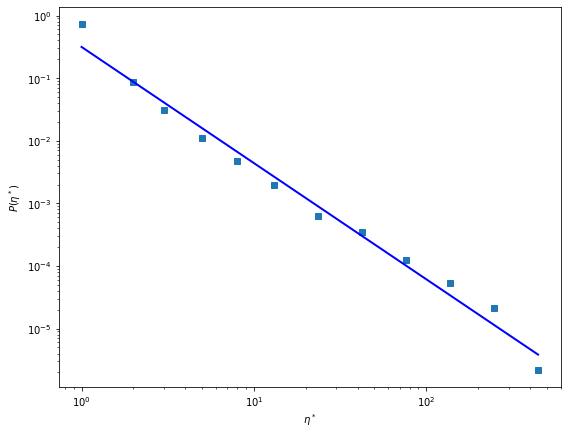

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(etaBins[:-1], etaHist, marker='s', linestyle='', color='C0')
etaReg = linregress(np.log(etaBins[:-1]), np.log(etaHist))
ax.plot(etaBins[:-1], np.exp(etaReg.intercept)*np.power(etaBins[:-1], etaReg.slope), 
        color='blue', linestyle='-', linewidth=2)
ax.set(xscale='log', yscale='log', xlabel=r'$\eta^*$', ylabel=r'$P(\eta^*)$')

print(f'Power-law exponent = {round(etaReg.slope, 2)}')

plt.show()

In [8]:
# P(tau)
interTime = []
for post in reel:
    amount = len(deltaGiver[post])
    if amount > 0:
        idxs = sorted(deltaGiver[post])
        interTime.append(deltaDay[post][0])
        for i in range(1, amount):
            interTime.append(deltaDay[post][i] - deltaDay[post][i - 1])

bins = [1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144]
interHist, interBins = np.histogram(interTime, bins=bins, density=True)

Power-law exponent = -2.02


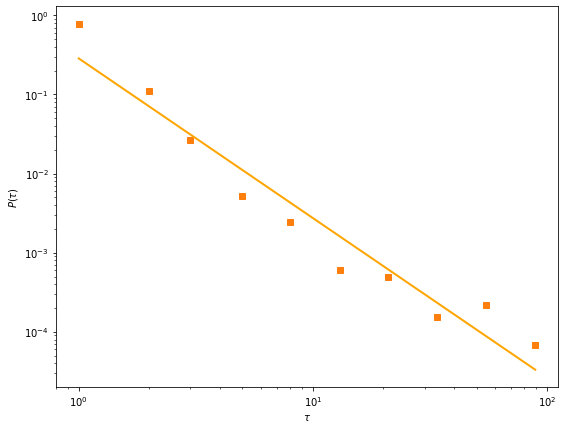

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(interBins[:-1], interHist, marker='s', linestyle='', color='C1')
interReg = linregress(np.log(interBins[:-1]), np.log(interHist))
ax.plot(interBins[:-1], np.exp(interReg.intercept)*np.power(interBins[:-1], interReg.slope), 
        color='orange', linestyle='-', linewidth=2)
ax.set(xscale='log', yscale='log', xlabel=r'$\tau$', ylabel=r'$P(\tau)$')

print(f'Power-law exponent = {round(interReg.slope, 2)}')
plt.show()

In [10]:
# P(m)
interComment = []
for u in range(Nuser):
    amount = len(deltaReceiver[u])
    if amount > 0:
        idx0 = userTrack[u].index(deltaReceiver[u][0])
        interComment.append(idx0)
        for i in range(1,amount):
            idx0, idx1 = userTrack[u].index(deltaReceiver[u][i - 1]), userTrack[u].index(deltaReceiver[u][i])
            interComment.append(idx1 - idx0)

bins = np.concatenate((np.array([1, 2, 3, 5, 8]), np.geomspace(13, max(interComment), 11)))
interHist, interBins = np.histogram(interComment, bins=bins, density=True)

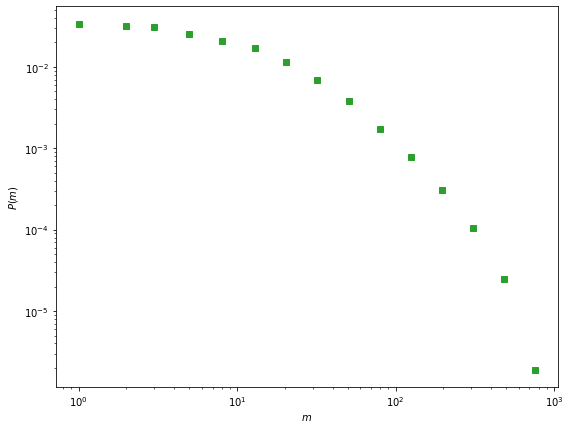

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(interBins[:-1], interHist, marker='s', linestyle='', color='C2')
ax.set(xscale='log', yscale='log', xlabel=r'$m$', ylabel=r'$P(m)$')

plt.show()